# 01 Preprocessing - MNIST Dataset

This notebook covers loading, visualizing, and preprocessing the MNIST handwritten digits dataset for our neural network.

## 1. Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import os

## 2. Load the Dataset
We load the MNIST dataset which is built-in to Keras. It consists of 60,000 training images and 10,000 testing images.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Training images shape: {x_train.shape}")
print(f"Testing images shape: {x_test.shape}")
print(f"Initial label format: {y_train[0]} (a scalar digit)")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 23s 2us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Initial label format: 5 (a scalar digit)


## 3. Visualize Sample Images
Let's see what the data looks like.

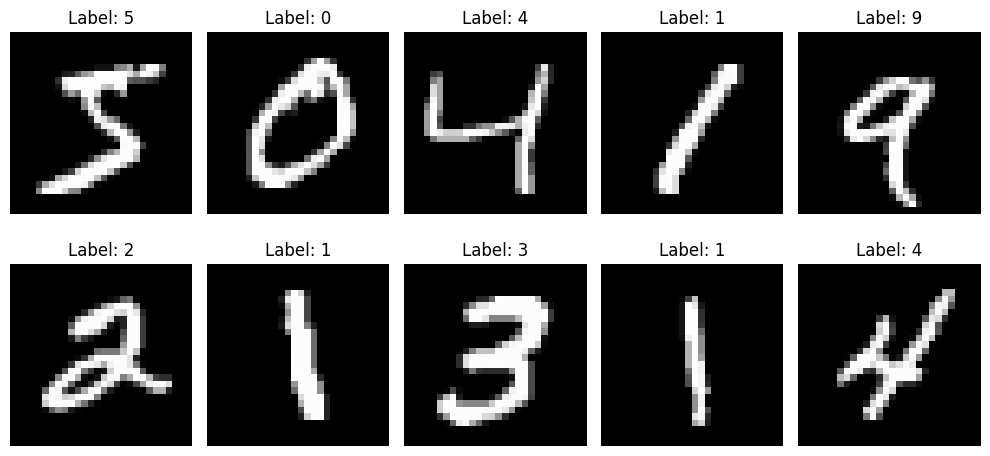

In [3]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Normalize and Reshape Data
Neural networks perform better when pixel values are scaled between 0 and 1. Also, we need to reshape the images to include a single color channel (for grayscale).

In [4]:
# Normalize to [0, 1] range
x_train_norm = x_train.astype('float32') / 255
x_test_norm = x_test.astype('float32') / 255

# Reshape to indicate single grayscale channel (28x28 -> 28x28x1)
x_train_reshaped = x_train_norm.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_norm.reshape(-1, 28, 28, 1)

print(f"Reshaped train shape: {x_train_reshaped.shape}")
print(f"Reshaped test shape: {x_test_reshaped.shape}")

Reshaped train shape: (60000, 28, 28, 1)
Reshaped test shape: (10000, 28, 28, 1)


## 5. One-Hot Encoding Labels
Converting digit labels (0-9) into a binary class matrix.

In [5]:
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

print(f"Original label: {y_train[0]}")
print(f"Categorical label: {y_train_cat[0]}")

Original label: 5
Categorical label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 6. Save Processed Data
We save the preprocessed arrays for use in the next notebook.

In [6]:
if not os.path.exists('../data'):
    os.makedirs('../data')

np.savez('../data/mnist_preprocessed.npz', 
         x_train=x_train_reshaped, 
         x_test=x_test_reshaped, 
         y_train=y_train_cat, 
         y_test=y_test_cat)

print("Preprocessed data saved to data/mnist_preprocessed.npz")

Preprocessed data saved to data/mnist_preprocessed.npz
